In [5]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score

from sklearn.ensemble import GradientBoostingClassifier


# Load dataset
df = pd.read_csv(r"C:\Users\Rounak\Downloads\archive (1)\sensor_Crop_Dataset (1).csv")


# Encode categorical columns
le_crop = LabelEncoder()
le_soil = LabelEncoder()
le_variety = LabelEncoder()

df["Crop"] = le_crop.fit_transform(df["Crop"])
df["Soil_Type"] = le_soil.fit_transform(df["Soil_Type"])
df["Variety"] = le_variety.fit_transform(df["Variety"])


# Features and target
X = df.drop("Crop", axis=1)
y = df["Crop"]


# Feature scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


# Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.2,
    random_state=42
)


# Gradient Boosting Model
model = GradientBoostingClassifier(
    n_estimators=300,
    learning_rate=0.1,
    max_depth=3
)


# Train model
model.fit(X_train, y_train)


# Predict
pred = model.predict(X_test)


# Accuracy
acc = accuracy_score(y_test, pred)

print("Gradient Boosting Accuracy:", acc)

Gradient Boosting Accuracy: 0.9605


In [6]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(model, X_scaled, y, cv=5)

print("Cross Validation Scores:", scores)
print("Mean CV Accuracy:", scores.mean())

Cross Validation Scores: [0.99425 0.997   0.995   0.99825 0.82475]
Mean CV Accuracy: 0.9618500000000001


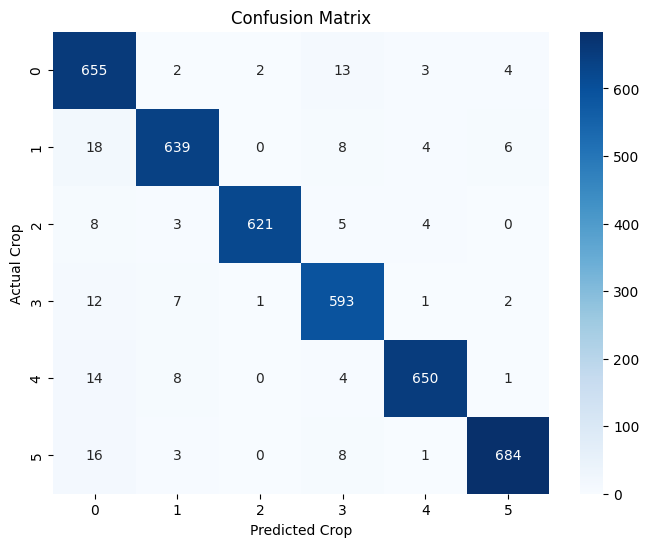

In [7]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.title("Confusion Matrix")
plt.xlabel("Predicted Crop")
plt.ylabel("Actual Crop")

plt.show()

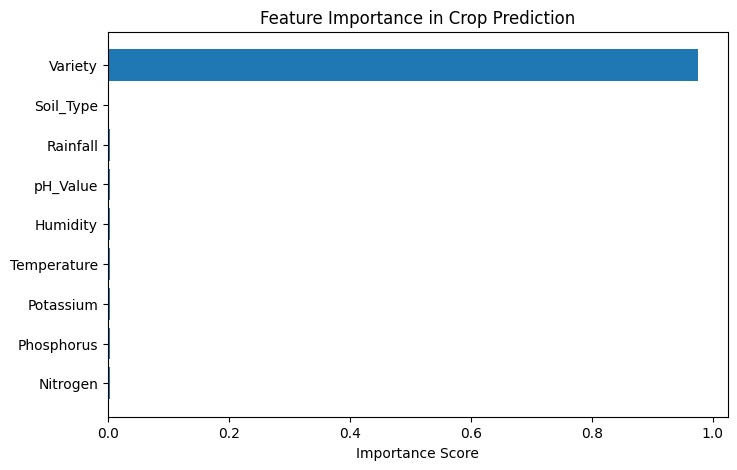

In [11]:
# 13 Feature Importance
# ===============================

importance = model.feature_importances_

features = X.columns

plt.figure(figsize=(8,5))

plt.barh(features, importance)

plt.title("Feature Importance in Crop Prediction")

plt.xlabel("Importance Score")

plt.show()